In [15]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/home/zonzin/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
from sklearn.tree import export_graphviz
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score

In [3]:
Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')

### Instanciando o classificador

In [4]:
dt_classificador = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42)

In [5]:
dt_classificador.fit(Xtrain, Ytrain)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [ ]:
"""export_graphviz(
    dt_classificador,
    out_file= "../results/decision_tree.dot",
    #feature_names=Xtest.columns,
    #class_names='',
    rounded=True,
    filled=True
)"""

In [11]:
y_train_pred_cv = cross_val_predict(dt_classificador, Xtrain, Ytrain, cv=3)

In [14]:
conf_mx = confusion_matrix(Ytrain, y_train_pred_cv)

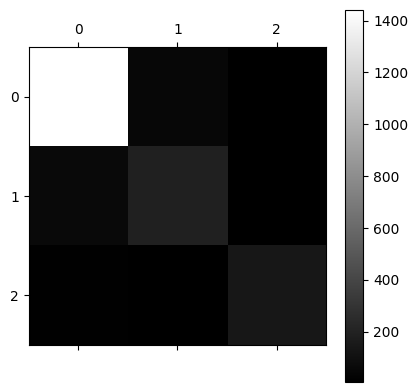

In [18]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.colorbar()

In [19]:
precision_score(Ytrain, y_train_pred_cv,  average='weighted')

0.9243143547066797

In [30]:
recall_score(Ytrain, y_train_pred_cv, labels = dt_classificador.classes_, average= 'weighted')

0.9252483010977522

In [17]:
ypredict = dt_classificador.predict(Xtest)

In [32]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report

In [34]:
print(classification_report(Ytest, ypredict))

              precision    recall  f1-score   support

           1       0.96      0.94      0.95       159
           2       0.81      0.83      0.82        36
           3       0.85      0.94      0.89        18

    accuracy                           0.92       213
   macro avg       0.87      0.91      0.89       213
weighted avg       0.93      0.92      0.93       213

